### Dealing with Missing Data

Before discussing several techniques for dealing with missing values, let's create a simple example from a CSV file:

In [1]:
import pandas as pd
from io import StringIO

csv_data = '''A,B,C,D
1.0,2.0,3.0,4.0
5.0,6.0,,8
10.0,11.0,12.0,'''
df = pd.read_csv(StringIO(csv_data))
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,NaN,8.0
2,10.0,11.0,12.0,NaN


Using the preceding code, we can read the CSV-formatted data to a pandas DataFrame. For a large dataframe, it would be tedious to look for missing values manually, so we can use the sum and isnull methods to get the number of missing values per column:

In [2]:
df.isnull().sum()

A    0
B    0
C    1
D    1
dtype: int64

### Eliminating Training Examples or Features with Missing Values

One of the easiest ways to deal with missing data is to simply remove the corresponding features (columns) or training examples (rows) for the dataset entirely. The dropna method with axis set to 0 drops the rows:

In [3]:
df.dropna(axis=0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


We can drop the columns similary by just setting the axis to 1:

In [4]:
df.dropna(axis=1)

,A,B
0,1.0,2.0
1,5.0,6.0
2,10.0,11.0


We can introduce additional parameters to the dropna method that can come in handy:

In [5]:
# only drop rows where all columns are NaN
# (returns the whole array here since we don't have a row with all values NaN)
df.dropna(how='all')

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,NaN,8.0
2,10.0,11.0,12.0,NaN


In [6]:
# drop rows that have fewer than 4 real values
df.dropna(thresh=4)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [7]:
# only drop rows where NaN appear in specific columns
df.dropna(subset=['C'])

,A,B,C,D
0,1.0,2.0,3.0,4.0
2,10.0,11.0,12.0,NaN


### Imputing Missing Values

Let's use scikit-learn's SimpleImputer class to achieve mean imputation:

In [8]:
from sklearn.impute import SimpleImputer
import numpy as np
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
imr.fit(df.values)
imputed_data = imr.transform(df.values)
imputed_data

array([[ 1. ,  2. ,  3. ,  4. ],
       [ 5. ,  6. ,  7.5,  8. ],
       [10. , 11. , 12. ,  6. ]])

Here, we replaced each NaN value with the corresponding mean, which is separately calculated for each feature column. Alternatively, an even more convenient way to impute missing values is by using pandas fillna method and providing an imputation as an argument:

In [9]:
df.fillna(df.mean())

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.5,8.0
2,10.0,11.0,12.0,6.0


### Handling Categorical Data

Let's make a new dataframe to explore how to handle categorical data:

In [10]:
import pandas as pd
df = pd.DataFrame([
    ['green', 'M', 10.1, 'class2'],
    ['red', 'L', 13.5, 'class1'],
    ['blue', 'XL', 15.3, 'class2']])

df.columns = ['color', 'size', 'price', 'classlabel']
df

,color,size,price,classlabel
0,green,M,10.1,class2
1,red,L,13.5,class1
2,blue,XL,15.3,class2


To make sure that the learning algorithm interprets the ordinal features correctly, we need to convert the categorical string values into integers:

In [11]:
size_mapping = {'XL': 3, 'L': 2, 'M': 1}
df['size'] = df['size'].map(size_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,class2
1,red,2,13.5,class1
2,blue,3,15.3,class2


For class labels, since they are nominal, it doesn't matter which integer number we assign to a particular class, we usually enumerate starting from 0:

In [12]:
import numpy as np
class_mapping = {label: idx for idx, label in enumerate(np.unique(df['classlabel']))}
df['classlabel'] = df['classlabel'].map(class_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,1
1,red,2,13.5,0
2,blue,3,15.3,1


There is also a LabelEncoder class directly implemented in scikit-learn to achieve this:

In [13]:
from sklearn.preprocessing import LabelEncoder
class_le = LabelEncoder()
y = class_le.fit_transform(df['classlabel'].values)
y

array([1, 0, 1])

Let's use one-hot encoder to transform the color column:

In [14]:
from sklearn.preprocessing import OneHotEncoder
X = df[['color', 'size', 'price']].values
color_ohe = OneHotEncoder()
color_ohe.fit_transform(X[:, 0].reshape(-1, 1)).toarray()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

We can also use ColumnTransformer class to selectively transform columns in a multi-feature array:

In [15]:
from sklearn.compose import ColumnTransformer
X = df[['color', 'size', 'price']].values
c_transf = ColumnTransformer([('onehot', OneHotEncoder(), [0]),
                              ('nothing', 'passthrough', [1, 2])])

c_transf.fit_transform(X).astype(float)

array([[ 0. ,  1. ,  0. ,  1. , 10.1],
       [ 0. ,  0. ,  1. ,  2. , 13.5],
       [ 1. ,  0. ,  0. ,  3. , 15.3]])

There is an even more convenient way to create dummy features via one-hot encoding:

In [16]:
pd.get_dummies(df[['price','color', 'size']])

,price,size,color_blue,color_green,color_red
0,10.1,1,False,True,False
1,13.5,2,False,False,True
2,15.3,3,True,False,False


Let's drop the first column to reduce multicollinearity:

In [17]:
pd.get_dummies(df[['price', 'color', 'size']], 
               drop_first=True)

,price,size,color_green,color_red
0,10.1,1,True,False
1,13.5,2,False,True
2,15.3,3,False,False


We can also drop the redundant column via OneHotEncoder class as such:

In [18]:
color_ohe = OneHotEncoder(categories='auto', drop='first')
c_transf = ColumnTransformer([
    ('onehot', color_ohe, [0]),
    ('nothing', 'passthrough', [1, 2])
])
c_transf.fit_transform(X).astype(float)

array([[ 1. ,  0. ,  1. , 10.1],
       [ 0. ,  1. ,  2. , 13.5],
       [ 0. ,  0. ,  3. , 15.3]])

### Partitioning a Dataset Into Separate Training and Test Datasets

Let's use the open-source Wine dataset from UCI machine learning repository:

In [19]:
df_wine = pd.read_csv('./wine.data', header=None)
df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash', 
                   'Alcalinity of ash', 'Magnesium', 
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols', 
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 
                   'Proline']

df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


The examples belong to one of the three different classes 1,2 and 3 which refer to the different types of grape. A convenient way to randomly partition this dataset into separate test and training datasets is to use the train_test_split function:

In [20]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    random_state=0, 
                                                    stratify=y)

### Bringing Features Onto the Same Scale

Let's apply normalization (min-max scaling) to our data as such:

In [21]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)

We can also implement standardization as well: 

In [22]:
from sklearn.preprocessing import StandardScaler
stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

### Sparse Solutions with L1 Regularization

For regularized models in scikit-learn that support L1 regularization, we can obtain a sparse solution by setting l1_ratio parameter to 1:

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

OneVsRestClassifier(LogisticRegression(l1_ratio = 1,
                                       solver='liblinear'))

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=No

We are using liblinear since lbfgs does not support L1-regularized optimization. Let's now apply the estimator to our Wine data:

In [24]:
lr = OneVsRestClassifier(LogisticRegression(l1_ratio = 1, 
                                            C=1.0,
                                            solver='liblinear'))
lr.fit(X_train_std, y_train)
print('Training accuracy:', lr.score(X_train_std, y_train))
print('Test accuracy:', lr.score(X_test_std, y_test))

Training accuracy: 1.0
Test accuracy: 1.0


Both training and test accuracies are 100 percent, indicating that our model does a perfect job on both datasets. When we access the intercept terms by using the intercept_ attribute for each estimator:

In [25]:
intercepts = np.concatenate([est.intercept_ for est in lr.estimators_])

intercepts

array([-1.2634831 , -1.21578781, -2.37057914])

The three intercepts are for the three classes. First intercept belongs to the model that fits class 1 versus class 2 and 3, the second intercept belongs to the model that fits class 2 versus class 1 and 3, and the third intercept belongs to the model that fits class 3 versus class 1 and 2. We can also gather the weight arrays for each model by using the coef_ attribute:

In [26]:
coefs = np.vstack([est.coef_ for est in lr.estimators_])

coefs

array([[ 1.24553054,  0.18009148,  0.74642902, -1.16408778,  0.        ,
         0.        ,  1.15809339,  0.        ,  0.        ,  0.        ,
         0.        ,  0.55796554,  2.50893155],
       [-1.53701393, -0.3878547 , -0.99512737,  0.36545746, -0.05978795,
         0.        ,  0.66799042,  0.        ,  0.        , -1.93411805,
         1.23298496,  0.        , -2.23090143],
       [ 0.13573968,  0.16846572,  0.35715078,  0.        ,  0.        ,
         0.        , -2.43805987,  0.        ,  0.        ,  1.56349852,
        -0.81905516, -0.49250193,  0.        ]])

We can see that using L1 regularization has caused sparcity and turned the weights of some features to 0, acting as a feature selection method. We could have enforced more sparsity by further increasing the regularization strength, that is, choosing lower values for the C parameter. Let's make a plot of the coefficients based on the regularization strength now:

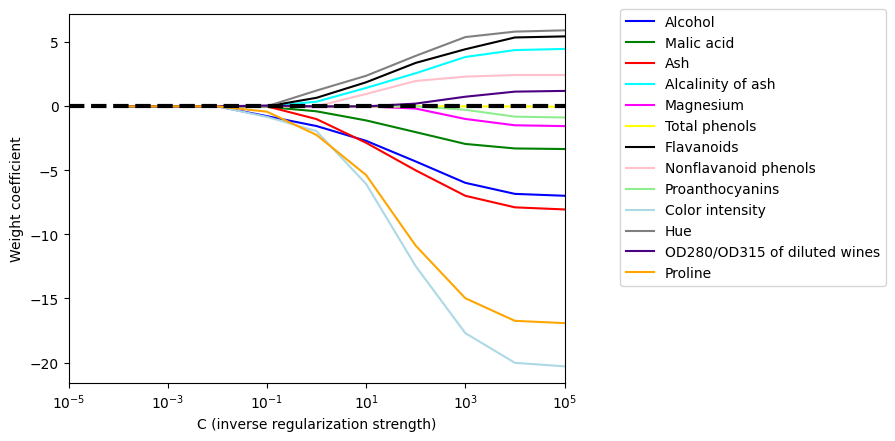

In [27]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.subplot(111)
colors = ['blue', 'green', 'red', 'cyan',
          'magenta', 'yellow', 'black', 
          'pink', 'lightgreen', 'lightblue',
          'gray', 'indigo', 'orange']
weights, params = [], []
for c in np.arange(-4., 6.):
    lr = OneVsRestClassifier(LogisticRegression(l1_ratio=1,
                                                C = 10**c,
                                                solver='liblinear',
                                                random_state=0))
    lr.fit(X_train_std, y_train)
    weights.append(lr.estimators_[1].coef_[0])
    params.append(10**c)

weights = np.array(weights)
for column, color in zip(range(weights.shape[1]), colors):
    plt.plot(params, weights[:, column],
             label=df_wine.columns[column + 1],
             color=color)
plt.axhline(0, color='black', linestyle='--', linewidth=3)
plt.xlim([10**(-5), 10**5])
plt.ylabel('Weight coefficient')
plt.xlabel('C (inverse regularization strength)')
plt.xscale('log')
plt.legend(loc='upper left')
ax.legend(loc='upper center',
          bbox_to_anchor=(1.38, 1.03),
          ncol=1, fancybox=True)
plt.show()

We can see that all feature weights will be zero if we penalize the model with a strong regularization parameter (small C).

### Sequential Feature Selection Algorithms

Let's go ahead and implement Sequential Backward Selection (SBS) algorithm from scratch now:

In [28]:
from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

class SBS:
    def __init__(self, estimator, k_features,
                 scoring=accuracy_score,
                 test_size=0.25,
                 random_state=1):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                            test_size=self.test_size,
                                                            random_state=self.random_state)
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train, X_test, y_test, self.indices_)
        self.scores_ = [score]
        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)
            
            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1

            self.scores_.append(scores[best])
        
        self.k_score_ = self.scores_[-1]

        return self
    
    def transform(self, X):
        return X[:, self.indices_]
    
    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score




In the preceding implementation, we defined k_features parameter to specify the desired number of features we want to return. By default, we use the accuracy_score metric to evaluate the performance of a model. Inside the while loop of the fit method, the feature subsets created by the itertools.combination function are evaluated and reduced until the feature subset has the desired dimensionality. In each iteration, the accuracy score of the best subset is collected in a list, self.scores_, based on the internally created test dataset X_test. Let's now see our implementation in action using the KNN classifier:

In [29]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=1)
sbs.fit(X_train_std, y_train)

Although our SBS implementation already splits the dataset into training and testing datasets, we feed the training dataset into it, which creates a validation set different from the initial test set. This approach is necessary to prevent our original test set from being a part of the training data.

Our SBS algorithm collects the scores of the best feature subset at each stage, so let's plot the classification accuracies now:

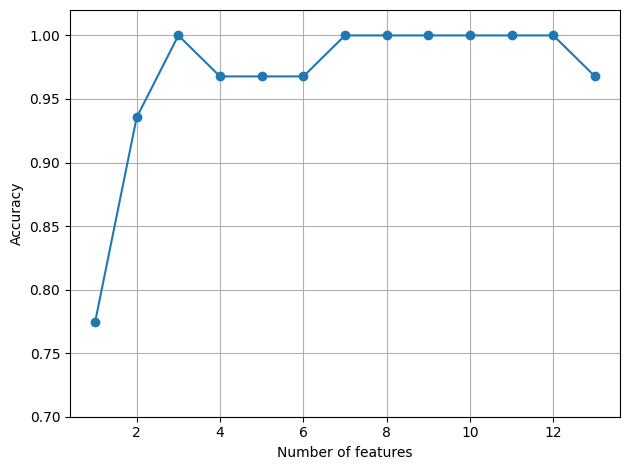

In [30]:
k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker = 'o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

As we can see, the accuracy of the KNN classifier improved on the validation dataset as we reduced the number of features, which is likely due to a decrease in the curse of dimensionality. 

We can check the smallest feature subset to see which features yielded the best performance:

In [31]:
k3 = list(sbs.subsets_[10])
print(df_wine.columns[1:][k3])

Index(['Alcohol', 'Malic acid', 'OD280/OD315 of diluted wines'], dtype='str')


Using the preceding code, we obtain the column indices of the three-feature subset from the 11th position in the sbs.subsets_ attribute and returned the corresponding feature names. Now let's evaluate the performance of the KNN classifier on the original test dataset:

In [32]:
knn.fit(X_train_std, y_train)
print('Training accuracy:', knn.score(X_train_std, y_train))
print('Test accuracy:', knn.score(X_test_std, y_test))

Training accuracy: 0.967741935483871
Test accuracy: 0.9629629629629629


In the preceding section, we used the complete feature set and obtained approximately 97% accuracy on the training dataset, and 96% on the test dataset, which indicates that our model already generalizes well to new data. Now, let's see the 3 feature subset and see how well KNN performs:

In [33]:
knn.fit(X_train_std[:, k3], y_train)
print('Training accuracy:', knn.score(X_train_std[:, k3], y_train))
print('Test accuracy:', knn.score(X_test_std[:, k3], y_test))

Training accuracy: 0.9516129032258065
Test accuracy: 0.9259259259259259


When using less than a quarter than of the original features in the Wine dataset, the prediction accuracy on the test dataset declined slightly. This may indicate that those three features do not provide less discriminatory information than the original dataset. However, we also have to keep in mind that the Wine dataset is a small dataset and is very susceptible to randomness, that is, the way we split the dataset into training and testing subsets, and how we split the training dataset further into a training and validation subset.

### Assessing Feature Importance with Random Forests

Random forest implementation in scikit-learn already collects the feature importance values for us so that we can access them via the feature_importances_ attribute after fitting a RandomForestClassifier. Let's train a random forest with 500 trees on the Wine dataset and rank the 13 features by their respective importance measures.

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


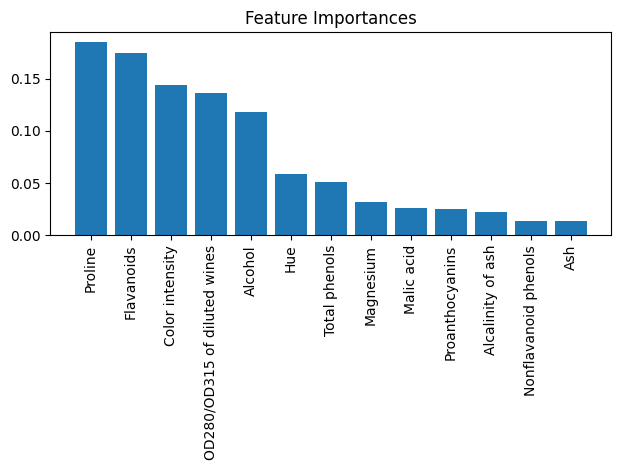

In [34]:
from sklearn.ensemble import RandomForestClassifier
feat_labels = df_wine.columns[1:]
forest = RandomForestClassifier(n_estimators=500,
                                random_state=1)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))

plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

We get a plot that ranks the different features in the Wine dataset by their relative importance, note that the feature importance values are normalized so that they sum up to 1.

We can conclude that the proline and flavonoid levels, color intensity, the OD280/OD315 diffraction, and the alcohol contentration of wine are the most discriminative features in the dataset based on the average impurity decrease in the 500 decision trees. Interestingly, the two of the top ranked features in the plot are also in the 3 feature subset selection from the SBS algorithm that we implemented in the previous section. 

It is also worth mentioning that we can use scikit-learn's SelectFromModel object that selects features based on a user-specified threshold after model fitting, which is useful if we want to use RandomForestClassifier as a feature selector and intermediate step in a scikit-learn Pipeline object, which allows us to connect different preprocessing steps with an estimator. Here is an example that reduces the dataset to 5 most important features:

In [35]:
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(forest, threshold=0.1, prefit=True)
X_selected = sfm.transform(X_train)
print('Number of features that meet this threshold', 
      'criterion:', X_selected.shape[1])

for f in range(X_selected.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))

Number of features that meet this threshold criterion: 5
 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
